In [1]:
# pandas → DMI 통합 데이터를 표 형태로 관리
# numpy → 실습용 가상 데이터 생성 및 수치 계산
# matplotlib → 데이터 관계 시각화
# sklearn → 수율 예측 모델 학습 및 평가

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# 실제 defect_metrology_yield.csv가 없으므로
# D(Defect), M(Metrology), I(Inspection)를 가정한
# 실습용 가상 데이터를 생성
#
# 실행할 때마다 동일한 결과가 나오도록 난수 고정

np.random.seed(42)

n = 500

df = pd.DataFrame({
    # D : Defect 관련 데이터
    'TOTAL_DEFECT_COUNT': np.random.poisson(12, n),
    'KILLER_DEFECT_COUNT': np.random.poisson(2, n),
    'DEFECT_DENSITY': np.random.uniform(0.05, 0.8, n),

    # M : Metrology 관련 데이터
    'CD_MEAN': np.random.normal(40, 1.5, n),
    'CD_3SIGMA': np.random.uniform(1.0, 5.0, n),
    'OVERLAY_TOTAL': np.random.uniform(1.0, 8.0, n),
    'FILM_THICKNESS_NU': np.random.uniform(0.5, 5.0, n),

    # 이전 공정 이력을 단순화한 데이터
    'CUMULATIVE_DEFECT_LAYER1': np.random.poisson(5, n),
    'CUMULATIVE_DEFECT_LAYER2': np.random.poisson(8, n),
    'ETCH_RATE_DEVIATION': np.random.normal(0, 2, n)
})

df.head()

,TOTAL_DEFECT_COUNT,KILLER_DEFECT_COUNT,DEFECT_DENSITY,CD_MEAN,CD_3SIGMA,OVERLAY_TOTAL,FILM_THICKNESS_NU,CUMULATIVE_DEFECT_LAYER1,CUMULATIVE_DEFECT_LAYER2,ETCH_RATE_DEVIATION
0,11,3,0.619082,38.773899,1.645469,3.933696,3.187906,3,7,-0.842061
1,14,3,0.261872,39.085648,3.287984,5.195095,2.271360,4,8,-2.995098
2,8,2,0.314788,38.480026,4.221729,4.595955,2.630460,6,8,1.526486
3,13,2,0.720571,41.051779,4.040644,3.017292,4.345463,8,12,2.830696
4,16,2,0.759842,37.711105,1.615600,1.045251,2.030020,3,4,0.040031


In [3]:
# 검사/계측 값이 악화될수록
# Final Yield가 감소하는 관계를 가정
#
# 아래 식은 실제 FAB 수율 공식이 아니라
# 머신러닝 실습을 위한 가상 관계식

yield_noise = np.random.normal(0, 1.5, n)

df['FINAL_YIELD'] = (
    98
    - 0.25 * df['TOTAL_DEFECT_COUNT']
    - 1.20 * df['KILLER_DEFECT_COUNT']
    - 3.00 * df['DEFECT_DENSITY']
    - 0.35 * df['CD_3SIGMA']
    - 0.25 * df['OVERLAY_TOTAL']
    - 0.20 * df['FILM_THICKNESS_NU']
    - 0.15 * df['CUMULATIVE_DEFECT_LAYER1']
    - 0.10 * df['CUMULATIVE_DEFECT_LAYER2']
    - 0.20 * np.abs(df['ETCH_RATE_DEVIATION'])
    + yield_noise
)

# 수율 범위를 0~100%로 제한
df['FINAL_YIELD'] = df['FINAL_YIELD'].clip(0, 100)

df.head()

,TOTAL_DEFECT_COUNT,KILLER_DEFECT_COUNT,DEFECT_DENSITY,CD_MEAN,CD_3SIGMA,OVERLAY_TOTAL,FILM_THICKNESS_NU,CUMULATIVE_DEFECT_LAYER1,CUMULATIVE_DEFECT_LAYER2,ETCH_RATE_DEVIATION,FINAL_YIELD
0,11,3,0.619082,38.773899,1.645469,3.933696,3.187906,3,7,-0.842061,86.248681
1,14,3,0.261872,39.085648,3.287984,5.195095,2.271360,4,8,-2.995098,84.425102
2,8,2,0.314788,38.480026,4.221729,4.595955,2.630460,6,8,1.526486,88.722507
3,13,2,0.720571,41.051779,4.040644,3.017292,4.345463,8,12,2.830696,83.468270
4,16,2,0.759842,37.711105,1.615600,1.045251,2.030020,3,4,0.040031,85.721488


In [4]:
# 데이터 크기와 컬럼 확인

print("데이터 크기:", df.shape)

print("\n컬럼 목록:")
print(df.columns.tolist())

print("\n결측치:")
print(df.isnull().sum())

df.describe()

데이터 크기: (500, 11)

컬럼 목록:
['TOTAL_DEFECT_COUNT', 'KILLER_DEFECT_COUNT', 'DEFECT_DENSITY', 'CD_MEAN', 'CD_3SIGMA', 'OVERLAY_TOTAL', 'FILM_THICKNESS_NU', 'CUMULATIVE_DEFECT_LAYER1', 'CUMULATIVE_DEFECT_LAYER2', 'ETCH_RATE_DEVIATION', 'FINAL_YIELD']

결측치:
TOTAL_DEFECT_COUNT          0
KILLER_DEFECT_COUNT         0
DEFECT_DENSITY              0
CD_MEAN                     0
CD_3SIGMA                   0
OVERLAY_TOTAL               0
FILM_THICKNESS_NU           0
CUMULATIVE_DEFECT_LAYER1    0
CUMULATIVE_DEFECT_LAYER2    0
ETCH_RATE_DEVIATION         0
FINAL_YIELD                 0
dtype: int64


,TOTAL_DEFECT_COUNT,KILLER_DEFECT_COUNT,DEFECT_DENSITY,CD_MEAN,CD_3SIGMA,OVERLAY_TOTAL,FILM_THICKNESS_NU,CUMULATIVE_DEFECT_LAYER1,CUMULATIVE_DEFECT_LAYER2,ETCH_RATE_DEVIATION,FINAL_YIELD
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,11.800000,2.018000,0.423844,39.928422,2.947333,4.503538,2.733770,4.862000,8.070000,-0.129426,86.835725
std,3.491186,1.411971,0.211791,1.449513,1.132701,2.036062,1.279649,1.918937,2.738631,1.995992,2.692478
min,2.000000,0.000000,0.050009,35.012866,1.000123,1.001589,0.527827,0.000000,1.000000,-4.826896,76.861329
25%,9.000000,1.000000,0.239922,38.986332,1.957821,2.737016,1.734656,4.000000,6.000000,-1.500477,85.103721
50%,12.000000,2.000000,0.430243,39.888165,3.000475,4.395119,2.665799,5.000000,8.000000,-0.122018,86.849932
75%,14.000000,3.000000,0.599871,40.962336,3.794110,6.319084,3.802949,6.000000,10.000000,1.178990,88.697584
max,22.000000,7.000000,0.797887,44.592920,4.990998,7.978646,4.994568,12.000000,16.000000,5.834066,94.674228


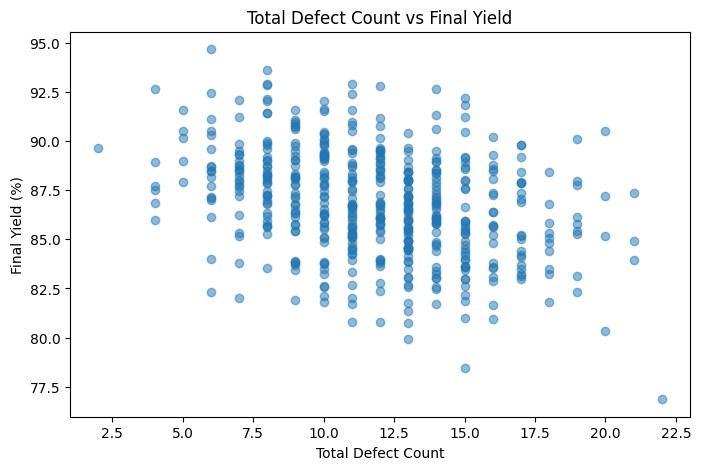

In [5]:
# Total Defect Count가 증가할수록
# Final Yield가 어떻게 변하는지 확인

plt.figure(figsize=(8, 5))

plt.scatter(
    df['TOTAL_DEFECT_COUNT'],
    df['FINAL_YIELD'],
    alpha=0.5
)

plt.xlabel('Total Defect Count')
plt.ylabel('Final Yield (%)')
plt.title('Total Defect Count vs Final Yield')

plt.show()

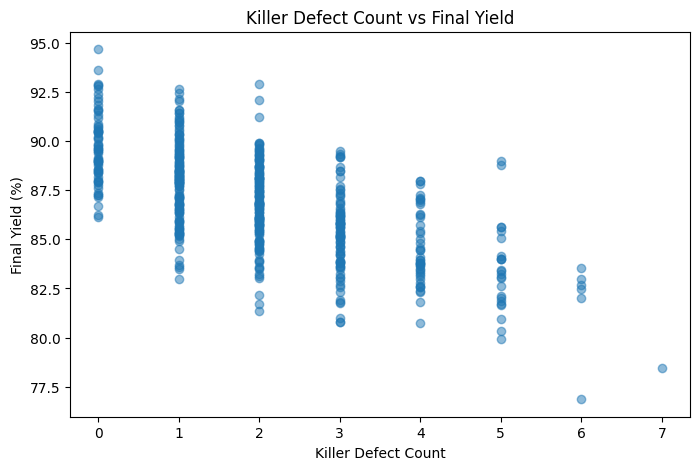

In [6]:
# 일반 Defect보다 수율에 직접적인 영향을 줄 수 있는
# Killer Defect와 Final Yield 관계 확인

plt.figure(figsize=(8, 5))

plt.scatter(
    df['KILLER_DEFECT_COUNT'],
    df['FINAL_YIELD'],
    alpha=0.5
)

plt.xlabel('Killer Defect Count')
plt.ylabel('Final Yield (%)')
plt.title('Killer Defect Count vs Final Yield')

plt.show()

In [7]:
# 주요 DMI 데이터와 Final Yield의
# 상관계수를 계산하여 영향 방향 확인

corr = df.corr(numeric_only=True)['FINAL_YIELD']

corr = corr.sort_values()

print("Final Yield와의 상관계수:")
print(corr.round(3))

Final Yield와의 상관계수:
KILLER_DEFECT_COUNT        -0.672
TOTAL_DEFECT_COUNT         -0.347
DEFECT_DENSITY             -0.221
OVERLAY_TOTAL              -0.184
CUMULATIVE_DEFECT_LAYER2   -0.164
FILM_THICKNESS_NU          -0.142
CUMULATIVE_DEFECT_LAYER1   -0.072
CD_3SIGMA                  -0.065
CD_MEAN                     0.010
ETCH_RATE_DEVIATION         0.016
FINAL_YIELD                 1.000
Name: FINAL_YIELD, dtype: float64


음의 상관관계가 큰 변수가 있으면

변수 증가
   ↓
공정 품질 악화
   ↓
Final Yield 감소

In [8]:
# 수율 예측에 사용할 Feature 정의

feature_cols = [
    'TOTAL_DEFECT_COUNT',
    'KILLER_DEFECT_COUNT',
    'DEFECT_DENSITY',
    'CD_MEAN',
    'CD_3SIGMA',
    'OVERLAY_TOTAL',
    'FILM_THICKNESS_NU',
    'CUMULATIVE_DEFECT_LAYER1',
    'CUMULATIVE_DEFECT_LAYER2',
    'ETCH_RATE_DEVIATION'
]

# X → 수율 예측에 사용할 입력 데이터
# y → 예측하고 싶은 최종 수율

X = df[feature_cols]
y = df['FINAL_YIELD']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 10)
y shape: (500,)


In [9]:
# 전체 데이터 중
# 80% → 모델 학습
# 20% → 학습하지 않은 데이터에서 성능 평가

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (400, 10)
Test : (100, 10)


In [10]:
# 여러 개의 약한 Decision Tree를 순차적으로 결합하여
# 예측 오차를 줄여가는 Gradient Boosting 모델 사용

model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# Test 데이터 수율 예측
y_pred = model.predict(X_test)

In [11]:
# MAE
# → 실제 수율과 예측 수율이 평균적으로
#    몇 %p 정도 차이나는지 확인
#
# R²
# → 모델이 수율 변동을 어느 정도 설명하는지 확인

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE : {mae:.3f} %p")
print(f"R²  : {r2:.3f}")

MAE : 1.310 %p
R²  : 0.629


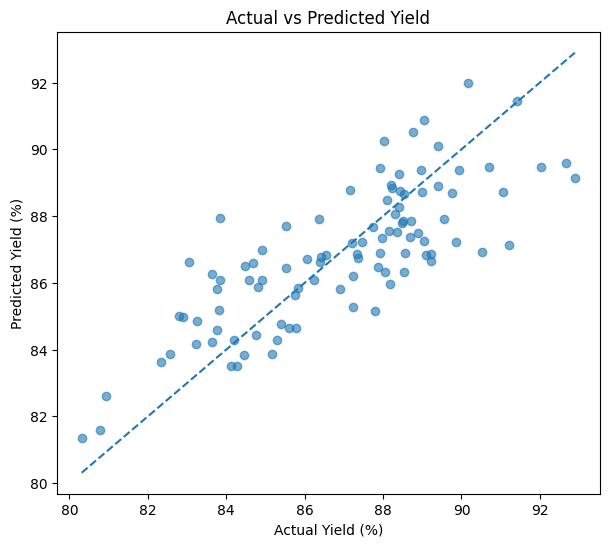

In [12]:
# 예측이 정확할수록 점들이
# y = x 형태의 대각선 주변에 모이게 됨

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_y = min(y_test.min(), y_pred.min())
max_y = max(y_test.max(), y_pred.max())

plt.plot(
    [min_y, max_y],
    [min_y, max_y],
    '--'
)

plt.xlabel('Actual Yield (%)')
plt.ylabel('Predicted Yield (%)')
plt.title('Actual vs Predicted Yield')

plt.show()

In [13]:
# 모델이 수율 예측 과정에서
# 어떤 변수를 상대적으로 많이 사용했는지 확인

importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("Feature Importance:")
print(importance.round(4))

Feature Importance:
KILLER_DEFECT_COUNT         0.3969
TOTAL_DEFECT_COUNT          0.1351
OVERLAY_TOTAL               0.0826
DEFECT_DENSITY              0.0783
CD_3SIGMA                   0.0731
FILM_THICKNESS_NU           0.0714
ETCH_RATE_DEVIATION         0.0485
CUMULATIVE_DEFECT_LAYER2    0.0470
CD_MEAN                     0.0348
CUMULATIVE_DEFECT_LAYER1    0.0323
dtype: float64


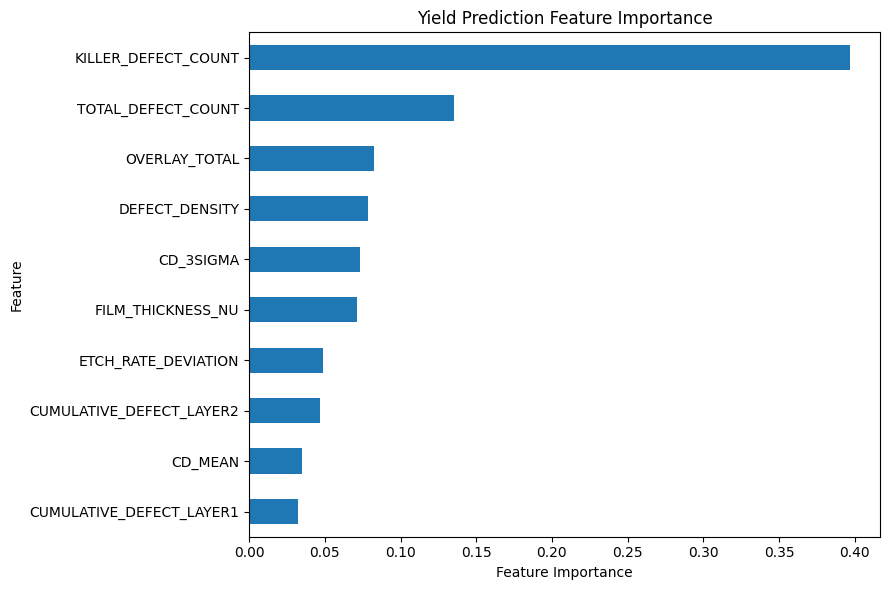

In [14]:
# 수율 예측에 중요한 변수 시각화

plt.figure(figsize=(9, 6))

importance.sort_values().plot(
    kind='barh'
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Yield Prediction Feature Importance')

plt.tight_layout()
plt.show()

## 분석 결과 요약

- Defect, Metrology 및 이전 공정 이력을 통합한 DMI 형태의 데이터를 구성하였다.
- Gradient Boosting Regression을 이용하여 Final Yield를 예측하였다.
- MAE와 R²를 이용하여 모델의 예측 성능을 평가하였다.
- Feature Importance를 통해 수율 예측에 상대적으로 영향이 큰 공정·검사 변수를 확인하였다.
- 실제 FAB 데이터 적용 시 검사·계측 데이터와 공정 이력을 연결하여 수율 저하 원인 추적에 활용할 수 있다.

> ※ 본 분석의 데이터는 실제 FAB 측정 데이터가 아닌 학습용 가상 데이터이며,
> Feature Importance는 인과관계를 의미하지 않는다.